# gemma4:e4b — where the pipeline gets it wrong

Two things, in order:

1. **The confusion matrix** — every real item, sorted by what the pipeline actually
   labeled it as. This is the fastest way to tell if the pipeline works: a matrix that's
   almost all diagonal means it's labeling correctly; a matrix with a lot of weight
   elsewhere means it's systematically confusing two particular label types.
2. **Only the items that didn't get labeled correctly**, one row per item, across all 10
   samples — no items that matched are shown.

Both cover **Path B**: the pipeline's final output (after the annotation rules run),
checked against the revised answer key.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import LABELS, extract_gold, _match_structured
from dmpbridge.evaluation.annotation_rules import (
    load_method_new, convert_tag_to_final, resolve_new_gt_path,
)

MODEL, TAG = 'gemma4:e4b', 'gemma4-e4b_pdfplumber_whole_doc'
SAMPLES = range(1, 11)

pd.set_option('display.max_colwidth', None)   # never truncate the text column
INK, SURFACE = '#0b0b0b', '#fcfcfb'

df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
if df_b is None:
    convert_tag_to_final(TAG)
    df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
print(f'{MODEL}: {len(df_b)} documents scored')


gemma4:e4b: 10 documents scored


## 1. Confusion matrix — raw counts

Rows are the true label, columns are what the pipeline actually produced.
**The `(not labeled)` column is items the pipeline never produced anything for at
all** — it isn't a label choice, it's the absence of one. Read across a row to see
everything that happened to one true class; the diagonal cell is how many it got right.


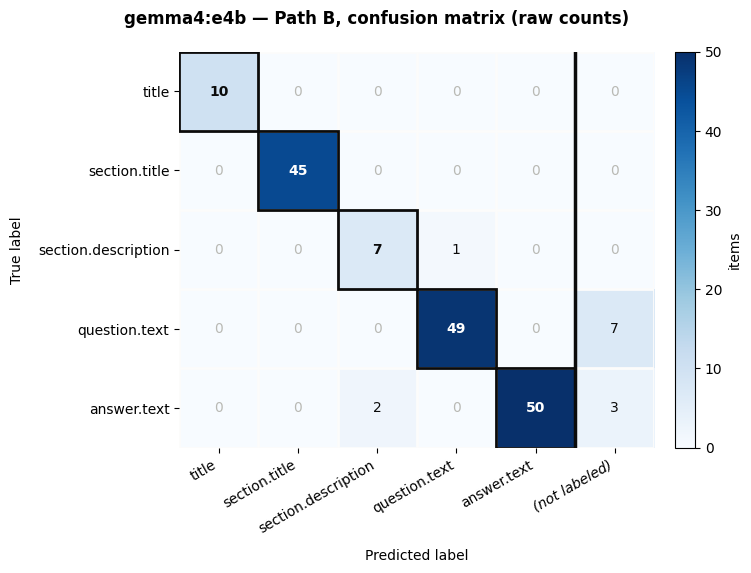

In [2]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']

counts = np.zeros((len(LABELS), len(KEYS)), dtype=int)
for i, t in enumerate(LABELS):
    for j, key in enumerate(KEYS):
        counts[i, j] = conf_b.get(t, {}).get(key, 0)

fig, ax = plt.subplots(figsize=(7.6, 5.8))
im = ax.imshow(counts, cmap='Blues', vmin=0, vmax=counts.max())
for i in range(len(LABELS)):
    for j in range(len(KEYS)):
        v = int(counts[i, j])
        ax.text(j, i, str(v) if v else '0', ha='center', va='center', fontsize=10,
                fontweight='bold' if i == j else 'normal',
                color='#b9b9b4' if v == 0 else ('white' if v / counts.max() > 0.55 else INK))

ax.set_xticks(range(len(COLS)))
ax.set_xticklabels(COLS, rotation=30, ha='right')
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted label', labelpad=10)
ax.set_ylabel('True label', labelpad=10)

ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2)
ax.tick_params(which='minor', length=0)
for k in range(len(LABELS)):
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=2.0, zorder=5))
ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
ax.get_xticklabels()[-1].set_style('italic')
for spine in ax.spines.values():
    spine.set_visible(False)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='items')
fig.suptitle(f'{MODEL} \u2014 Path B, confusion matrix (raw counts)', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Items not labeled correctly

One row per item, only where the pipeline's answer disagrees with the answer key —
either it labeled the text as the wrong type, produced nothing for a real item, or
produced an item the answer key doesn't have at all.

**Only the first two of those three (`wrong label`, `missing`) are the errors the
matrix above can show.** The matrix has one row per *real* (answer-key) item, so a
wrong label shows up off the diagonal and a missing item shows up in `(not labeled)`.
`extra — not in answer key` items have no real item to be a row of at all — they're
the pipeline producing something nobody asked for — so they exist only in the table
below, never in the matrix. That's the whole reason the two totals don't match.


In [3]:
rows = []
for n in SAMPLES:
    gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
    records, no_gold = _match_structured(P.final_path(TAG, n), gold, dedup_question_title=False)
    for r in records:
        if r['pred_text'] is None:
            rows.append({'sample': n, 'true label': r['gold_label'],
                         'predicted label': '(not produced)', 'issue': 'missing',
                         'text': r['gold_text']})
        elif r['pred_label'] != r['gold_label']:
            rows.append({'sample': n, 'true label': r['gold_label'],
                         'predicted label': r['pred_label'], 'issue': 'wrong label',
                         'text': r['pred_text']})
    for text, label in no_gold:
        rows.append({'sample': n, 'true label': '(none)', 'predicted label': label,
                     'issue': 'extra \u2014 not in answer key', 'text': text})

errors = pd.DataFrame(rows, columns=['sample', 'true label', 'predicted label', 'issue', 'text'])
total_gold = sum(len(extract_gold(resolve_new_gt_path(n), dedup_question_title=False)) for n in SAMPLES)
in_matrix = (errors['issue'] != 'extra \u2014 not in answer key').sum()
not_in_matrix = (errors['issue'] == 'extra \u2014 not in answer key').sum()
correct = total_gold - in_matrix

print(f'{total_gold} real (answer-key) items total \u2014 this is what the matrix rows sum to')
print(f'  {correct} correct (the matrix diagonal)')
print(f'  {in_matrix} wrong or missing (visible in the matrix, off-diagonal / "(not labeled)")')
print(f'  + {not_in_matrix} extra items with no real counterpart (NOT in the matrix at all)')
print(f'  = {len(errors)} rows in the table below')
print()
display(errors.groupby(['sample', 'issue']).size().unstack(fill_value=0))


174 real (answer-key) items total — this is what the matrix rows sum to
  161 correct (the matrix diagonal)
  13 wrong or missing (visible in the matrix, off-diagonal / "(not labeled)")
  + 6 extra items with no real counterpart (NOT in the matrix at all)
  = 19 rows in the table below



issue,extra — not in answer key,missing,wrong label
sample,,,
2,3,7,0
3,1,2,1
5,2,1,2


In [4]:
display(errors)


,sample,true label,predicted label,issue,text
0,2,question.text,(not produced),missing,Roles & Responsibilities.
1,2,question.text,(not produced),missing,"Rationale. A discussion of the rationale or justification for the proposed data management plan including, for example, the potential impact of the data within the immediate field and in other fields, and any broader societal impact."
2,2,answer.text,(not produced),missing,"The Department of Energy stipulates in their Statement on Digital Data Management that ""To the greatest extent and with the fewest constraints possible, and consistent with the requirements and other principles of this Statement, data sharing should make digital research data available to and useful for the scientific community, industry, and the public."" The Center will make every effort to comply with these guidelines. Data that is not deemed to be useful for a publication may still be archived at the discretion of the senior investigator overseeing the work, taking into the costs and benefits of doing so. The data acquired and preserved in the context of this proposal will be further governed by policies of the Northwestern University and its partner institutions pertaining to intellectual property, record retention, and data management."
3,2,question.text,(not produced),missing,Data Repositories.
4,2,answer.text,(not produced),missing,"Senior investigators typically archive relevant data using their own group servers. Whenever possible, investigators will be encouraged to also copy data to a centralized data server for CBES investigators. Additionally, researchers can archive data on repositories at their home institutions. For example, researchers at Northwestern are encouraged to deposit data into Northwestern Libraries' institutional repository, Arch, upon publication (https://arch.library.northwestern.edu/). Arch assigns DOIs, making it easy to find the data. Necessary metadata and other resources to make the data accessible to future users will be submitted. Arch will preserve the data for future use."
5,2,question.text,(not produced),missing,Data Volume.
6,2,answer.text,(not produced),missing,"Generally, the volume of data generated by CBES researchers should not prohibit their deposition in available repositories. However, in cases where large volumes of data are generated (e.g., temperature/time dependent microscopy or X-ray studies), the data may need to be averaged, condensed, or minimally processed prior to deposition."
7,2,(none),question.text,extra — not in answer key,1. Data sharing and preservation
8,2,(none),question.text,extra — not in answer key,3. Data management resources
9,2,(none),answer.text,extra — not in answer key,"DMPs should consult and reference available information about data management resources to be used in the course of the proposed research. In particular, DMPs that explicitly or implicitly commit data management resources at a facility beyond what is conventionally made available to approved users should be accompanied by written approval from that facility. In determining the resources available for data management at Office of Science User Facilities, researchers should consult the published description of data management resources and practices at that facility and reference it in the DMP. Information about other Office of Science facilities can be found in the additional guidance from the sponsoring program.\nData Repositories. Senior investigators typically archive relevant data using their own group servers. Whenever possible, investigators will be encouraged to also copy data to a centralized data server for CBES investigators. Additionally, researchers can archive data on repositories at their home institutions. For example, researchers at Northwestern are encouraged to deposit data into Northwestern Libraries’ institutional repository, Arch, upon publication (https://arch.library.northwestern.edu/). Arch assigns DOIs, making it easy to find the data. Nec